# Benchmarking organizations with the Dimensions API

This Python notebook shows how to use the [Dimensions Analytics API](https://www.dimensions.ai/dimensions-apis/) in order to perform different benchmarking analyses of Organizations using publications data. 

Outline

1. Quick yet effective benchmarking calculations via built-in API aggregate indicators
2. Building more complex quality benchmarking indicators 

In [1]:
import datetime
print("==\nCHANGELOG\nThis notebook was last run on %s\n==" % datetime.date.today().strftime('%b %d, %Y'))

==
CHANGELOG
This notebook was last run on Sep 10, 2025
==


## Prerequisites

This notebook assumes you have installed the [Dimcli](https://pypi.org/project/dimcli/) library and are familiar with the ['Getting Started' tutorial](https://api-lab.dimensions.ai/cookbooks/1-getting-started/1-Using-the-Dimcli-library-to-query-the-API.html).


In [2]:
!pip install dimcli -U --quiet 

import dimcli
from dimcli.utils import *
import os, sys, time, json
import pandas as pd

print("==\nLogging in..")
# https://digital-science.github.io/dimcli/getting-started.html#authentication
ENDPOINT = "https://app.dimensions.ai"
if 'google.colab' in sys.modules:
  import getpass
  KEY = getpass.getpass(prompt='API Key: ')  
  dimcli.login(key=KEY, endpoint=ENDPOINT)
else:
  KEY = ""
  dimcli.login(key=KEY, endpoint=ENDPOINT)
dsl = dimcli.Dsl()

Searching config file credentials for 'https://app.dimensions.ai' endpoint..


==
Logging in..
Dimcli - Dimensions API Client (v1.4)
Connected to: <https://app.dimensions.ai/api/dsl> - DSL v2.12
Method: dsl.ini file


## 1. Quick benchmarking using the API

Benchmarking by volume is reasonably straight forward if what you want to compare is volume, or one of the available aggregate indicators in the Dimensions API (see [https://docs.dimensions.ai/dsl/examples.html#indicators-aggregations](https://docs.dimensions.ai/dsl/examples.html#indicators-aggregations)).

In [3]:
%%dsldf
search publications
return research_orgs[name] aggregate altmetric_median 

Returned Research_orgs: 20
Time: 12.29s


,id,name,altmetric_median,count
0,grid.38142.3c,Harvard University,5.292790,715128
1,grid.26999.3d,The University of Tokyo,3.000000,570861
2,grid.17063.33,University of Toronto,4.019046,435895
3,grid.214458.e,University of Michigan-Ann Arbor,3.968242,412146
4,grid.168010.e,Stanford University,4.939072,393415
5,grid.4991.5,University of Oxford,5.104038,387324
6,grid.34477.33,University of Washington,4.304326,385718
7,grid.21107.35,Johns Hopkins University,4.374951,381545
8,grid.19006.3e,"University of California, Los Angeles",3.871221,373415
9,grid.258799.8,Kyoto University,3.000000,370973


In [4]:
%%dsldf
search publications
return research_orgs[name] aggregate citations_total

Returned Research_orgs: 20
Time: 4.16s


,id,name,citations_total,count
0,grid.38142.3c,Harvard University,43542715.0,715128
1,grid.26999.3d,The University of Tokyo,12416944.0,570861
2,grid.17063.33,University of Toronto,16896263.0,435895
3,grid.214458.e,University of Michigan-Ann Arbor,17899164.0,412146
4,grid.168010.e,Stanford University,22857822.0,393415
5,grid.4991.5,University of Oxford,17348878.0,387324
6,grid.34477.33,University of Washington,19245227.0,385718
7,grid.21107.35,Johns Hopkins University,18542871.0,381545
8,grid.19006.3e,"University of California, Los Angeles",17370426.0,373415
9,grid.258799.8,Kyoto University,8426700.0,370973


In [5]:
%%dsldf
search publications
return research_orgs[name] aggregate recent_citations_total

Returned Research_orgs: 20
Time: 5.11s


,id,name,count,recent_citations_total
0,grid.38142.3c,Harvard University,715128,5657002.0
1,grid.26999.3d,The University of Tokyo,570861,1498274.0
2,grid.17063.33,University of Toronto,435895,2557162.0
3,grid.214458.e,University of Michigan-Ann Arbor,412146,2411193.0
4,grid.168010.e,Stanford University,393415,3172519.0
5,grid.4991.5,University of Oxford,387324,2687354.0
6,grid.34477.33,University of Washington,385718,2508430.0
7,grid.21107.35,Johns Hopkins University,381545,2441471.0
8,grid.19006.3e,"University of California, Los Angeles",373415,2151381.0
9,grid.258799.8,Kyoto University,370973,966227.0


Aside:  Recent Citations


In [6]:
%%dsldf
search publications
return year aggregate recent_citations_total

Returned Year: 20
Time: 5.16s


,id,count,recent_citations_total
0,2024,7882763,13641369.0
1,2023,7755821,24571792.0
2,2022,7279681,26740821.0
3,2021,7016199,27057034.0
4,2020,6831663,25211581.0
5,2019,6004300,20340055.0
6,2018,5550132,17327713.0
7,2017,5171177,15030351.0
8,2025,5064609,1745079.0
9,2016,4775828,13029942.0


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='id'>

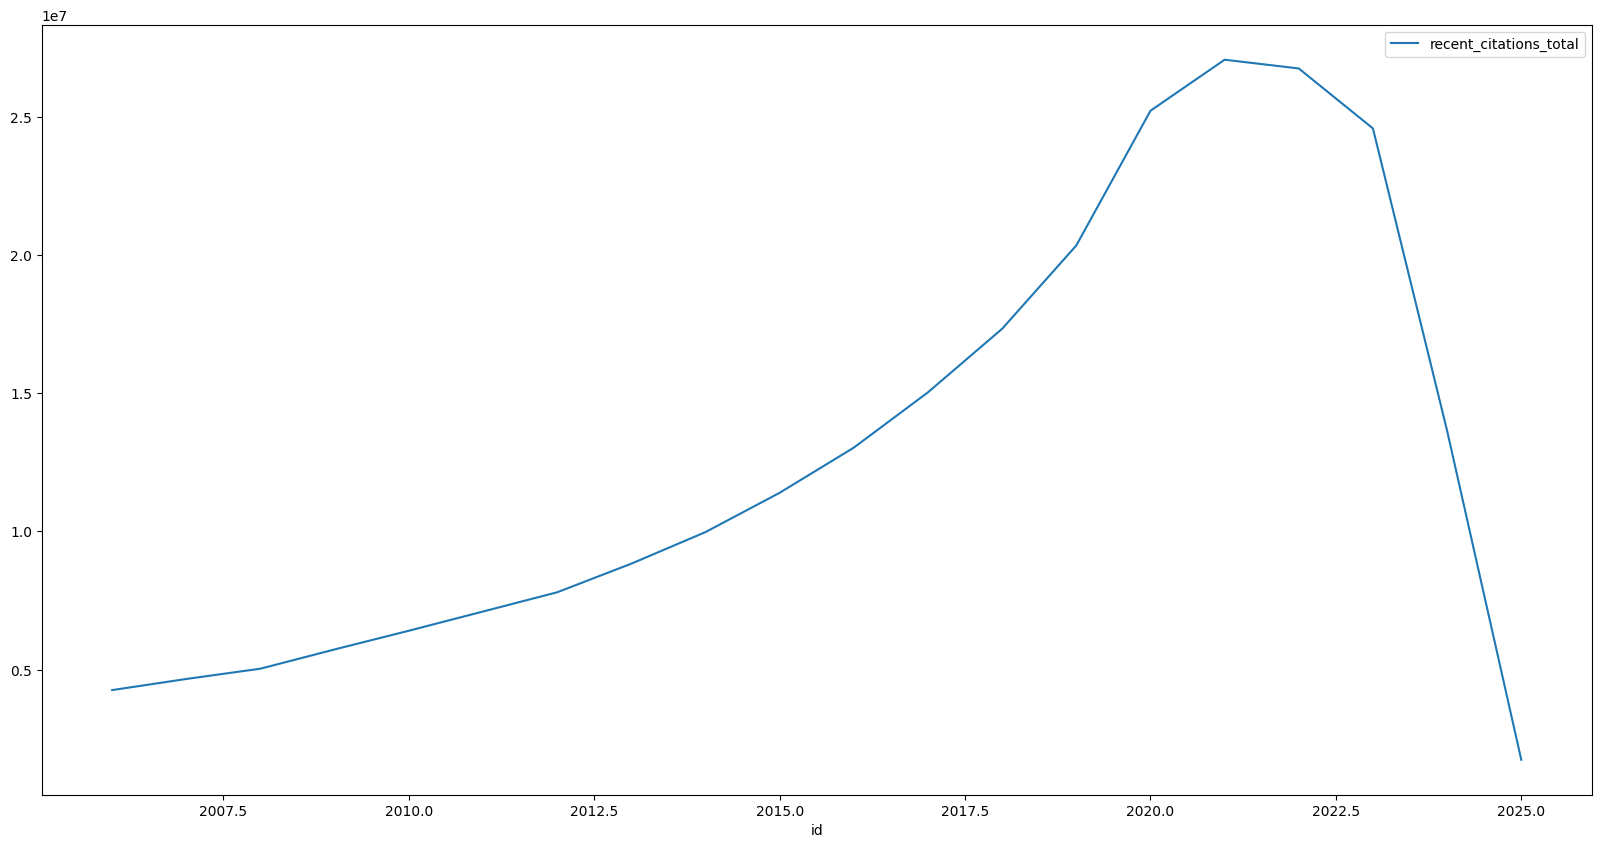

In [7]:
dsl_last_results.sort_values(by='id').plot(x='id', y='recent_citations_total', figsize=(20,10))

In [8]:
recent_citations = dsl_last_results

In [9]:
recent_citations['recent_ratio'] = recent_citations['recent_citations_total']/recent_citations['count']
recent_citations['year'] = recent_citations['id']

<Axes: xlabel='year'>

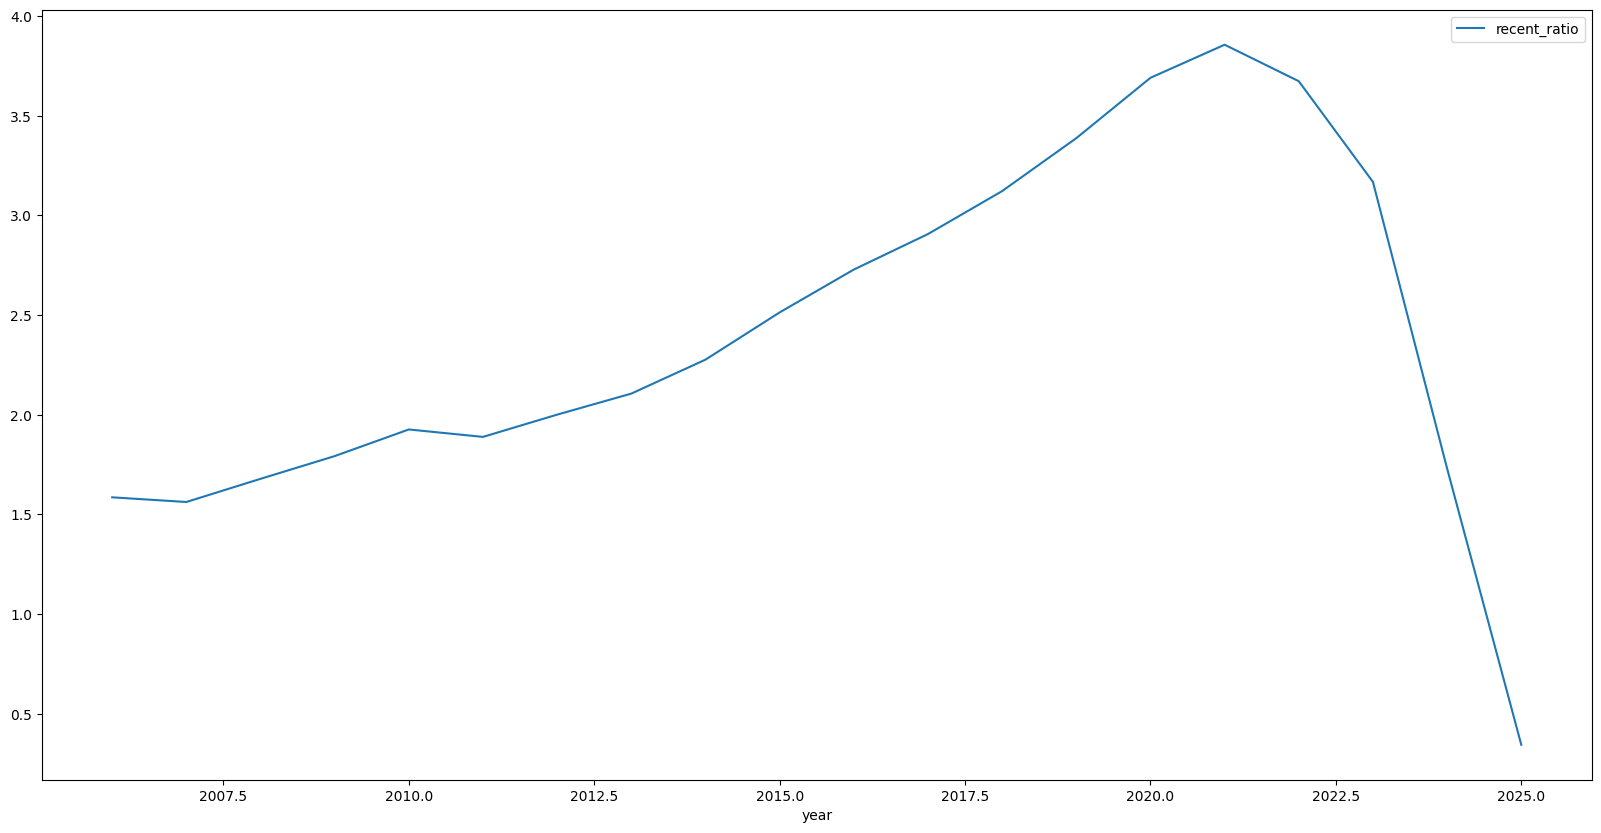

In [10]:
recent_citations.sort_values(by='year').\
    plot(x='year',y='recent_ratio', figsize=(20,10))

End Aside:

## 2. Calculating more complex 'Quality' Benchmarking indicators: Number of articles in the top X percent of research their category

### Step 1.  retrieve the total volume of publications by volume. (focusing on Fields of Research)

In [11]:
%%dsldf

search publications
where year=2018
return category_for limit 1000

Returned Category_for: 193
Time: 1.30s


,id,name,count
0,80003,32 Biomedical and Clinical Sciences,1094225
1,80011,40 Engineering,833052
2,80045,3202 Clinical Sciences,510399
3,80017,46 Information and Computing Sciences,425860
4,80002,31 Biological Sciences,365542
...,...,...,...
188,80201,4802 Environmental and Resources Law,6659
189,80129,4101 Climate Change Impacts and Adaptation,6626
190,80091,3702 Climate Change Science,6401
191,80131,4103 Environmental Biotechnology,5084


#### Step 1.2. ... Need to filter for level 2 codes

In [12]:
result = dsl.query("""
      search publications
      where year=2018
      return category_for limit 1000

""").as_dataframe()

Returned Category_for: 193
Time: 0.70s


In [13]:
result['level'] = result.name.apply(lambda n: len(n.split(' ')[0]))

In [14]:
result

,id,name,count,level
0,80003,32 Biomedical and Clinical Sciences,1094225,2
1,80011,40 Engineering,833052,2
2,80045,3202 Clinical Sciences,510399,4
3,80017,46 Information and Computing Sciences,425860,2
4,80002,31 Biological Sciences,365542,2
...,...,...,...,...
188,80201,4802 Environmental and Resources Law,6659,4
189,80129,4101 Climate Change Impacts and Adaptation,6626,4
190,80091,3702 Climate Change Science,6401,4
191,80131,4103 Environmental Biotechnology,5084,4


In [15]:
result[result['level']==2]

,id,name,count,level
0,80003,32 Biomedical and Clinical Sciences,1094225,2
1,80011,40 Engineering,833052,2
3,80017,46 Information and Computing Sciences,425860,2
4,80002,31 Biological Sciences,365542,2
5,80013,42 Health Sciences,304968,2
6,80005,34 Chemical Sciences,301217,2
7,80022,51 Physical Sciences,266544,2
8,80015,44 Human Society,227080,2
9,80006,"35 Commerce, Management, Tourism and Services",191148,2
10,80020,49 Mathematical Sciences,179411,2


### Step 2. calculate 1% of the total number of records by category. This will be used to retrieve the 1% boundary record..

What is the boundary record? 

In [16]:
result['cutoff'] = (result['count'] * .01).astype('int')

In [17]:
result[result['level']==2]

,id,name,count,level,cutoff
0,80003,32 Biomedical and Clinical Sciences,1094225,2,10942
1,80011,40 Engineering,833052,2,8330
3,80017,46 Information and Computing Sciences,425860,2,4258
4,80002,31 Biological Sciences,365542,2,3655
5,80013,42 Health Sciences,304968,2,3049
6,80005,34 Chemical Sciences,301217,2,3012
7,80022,51 Physical Sciences,266544,2,2665
8,80015,44 Human Society,227080,2,2270
9,80006,"35 Commerce, Management, Tourism and Services",191148,2,1911
10,80020,49 Mathematical Sciences,179411,2,1794


### Step 3. Use the cutoff value to get the indicator value for the 1% boundary

Note: Here we use:

'sort by' , limit, and skip!

*   'sort by': return results in order of field_citation_ratio
*   'limit': we are only interested in the first result returned
*   'skip' we are 'skipping' to the boundary record


Double Note: this strategy won't work when the boundary record is > 50,000...




In [18]:
dfl = []

for r in result[result['level']==2].iterrows():
    
    result = dsl.query(f"""
      
           search publications
           where category_for.id = "{r[1]['id']}"
           and year = 2018
           return publications[field_citation_ratio] 
               sort by field_citation_ratio 
               limit 1 
               skip {r[1]['cutoff']}
      
      """).as_dataframe()

    result['name'] = r[1]['name']
    result['id'] = r[1]['id']
    dfl.append(result)   
  

Returned Publications: 1 (total = 1094225)
Time: 6.21s
Returned Publications: 1 (total = 833052)
Time: 0.90s
Returned Publications: 1 (total = 425860)
Time: 5.81s
Returned Publications: 1 (total = 365542)
Time: 0.74s
Returned Publications: 1 (total = 304968)
Time: 0.66s
Returned Publications: 1 (total = 301217)
Time: 5.97s
Returned Publications: 1 (total = 266544)
Time: 6.07s
Returned Publications: 1 (total = 227080)
Time: 0.81s
Returned Publications: 1 (total = 191148)
Time: 5.18s
Returned Publications: 1 (total = 179411)
Time: 6.12s
Returned Publications: 1 (total = 165669)
Time: 6.00s
Returned Publications: 1 (total = 141809)
Time: 6.97s
Returned Publications: 1 (total = 138186)
Time: 0.59s
Returned Publications: 1 (total = 136222)
Time: 0.62s
Returned Publications: 1 (total = 117551)
Time: 6.13s
Returned Publications: 1 (total = 114877)
Time: 0.55s
Returned Publications: 1 (total = 99713)
Time: 0.57s
Returned Publications: 1 (total = 78815)
Time: 4.73s
Returned Publications: 1 (tot

In [19]:
cutoffs = pd.concat(dfl)

In [20]:
cutoffs

,field_citation_ratio,name,id
0,37.05,32 Biomedical and Clinical Sciences,80003
0,28.18,40 Engineering,80011
0,45.07,46 Information and Computing Sciences,80017
0,28.34,31 Biological Sciences,80002
0,33.82,42 Health Sciences,80013
0,25.02,34 Chemical Sciences,80005
0,38.91,51 Physical Sciences,80022
0,38.81,44 Human Society,80015
0,44.68,"35 Commerce, Management, Tourism and Services",80006
0,34.54,49 Mathematical Sciences,80020


#### We can only filter on integers in the DSL, so we will round up the values

In [21]:
cutoffs.field_citation_ratio =  cutoffs.field_citation_ratio.astype('int')

In [22]:
cutoffs

,field_citation_ratio,name,id
0,37,32 Biomedical and Clinical Sciences,80003
0,28,40 Engineering,80011
0,45,46 Information and Computing Sciences,80017
0,28,31 Biological Sciences,80002
0,33,42 Health Sciences,80013
0,25,34 Chemical Sciences,80005
0,38,51 Physical Sciences,80022
0,38,44 Human Society,80015
0,44,"35 Commerce, Management, Tourism and Services",80006
0,34,49 Mathematical Sciences,80020


### Step 4. Now get the number of publications by organisation, filtered by category that have a field_citation_ratio > the boundary score

In [23]:
dfl = []

for r in cutoffs.iterrows():

  result = dsl.query(f"""

     search publications 
     where 
         year=2018
         and category_for.id = "{r[1]['id']}"
         and field_citation_ratio >= {int(r[1]['field_citation_ratio'])}
    return research_orgs limit 1000

  """).as_dataframe()

  result['for_name'] = r[1]['name']
  result['for_id'] = r[1]['id']
  dfl.append(result)



Returned Research_orgs: 1000
Time: 6.15s
Returned Research_orgs: 1000
Time: 1.83s
Returned Research_orgs: 1000
Time: 5.51s
Returned Research_orgs: 1000
Time: 5.82s
Returned Research_orgs: 1000
Time: 1.56s
Returned Research_orgs: 1000
Time: 6.63s
Returned Research_orgs: 1000
Time: 1.82s
Returned Research_orgs: 1000
Time: 1.30s
Returned Research_orgs: 1000
Time: 1.37s
Returned Research_orgs: 1000
Time: 3.49s
Returned Research_orgs: 1000
Time: 1.73s
Returned Research_orgs: 1000
Time: 1.37s
Returned Research_orgs: 792
Time: 6.18s
Returned Research_orgs: 1000
Time: 1.29s
Returned Research_orgs: 764
Time: 1.06s
Returned Research_orgs: 953
Time: 4.22s
Returned Research_orgs: 1000
Time: 1.49s
Returned Research_orgs: 713
Time: 1.15s
Returned Research_orgs: 773
Time: 1.28s
Returned Research_orgs: 827
Time: 4.86s
Returned Research_orgs: 802
Time: 6.49s
Returned Research_orgs: 553
Time: 1.32s


ok, can only filter on Integrers

In [24]:
top_insts = pd.concat(dfl)

### Step 5. Rank the results

In [25]:
top_insts['rank'] = top_insts.groupby('for_name')['count'].rank(ascending=False)

In [26]:
top_insts[top_insts['name']=='University of Melbourne'][['for_name','rank']]

,for_name,rank
15,32 Biomedical and Clinical Sciences,16.0
173,40 Engineering,177.0
114,46 Information and Computing Sciences,121.0
18,31 Biological Sciences,19.0
12,42 Health Sciences,12.5
192,34 Chemical Sciences,212.0
142,51 Physical Sciences,148.0
10,44 Human Society,12.0
81,"35 Commerce, Management, Tourism and Services",90.5
125,49 Mathematical Sciences,142.0


#### We should probably control for Volume though...

### Step 6. Get the total paper counts for each organisation

In [27]:
dfl = []

for r in cutoffs.iterrows():

  result = dsl.query(f"""

     search publications 
     where 
         year=2018
         and category_for.id = "{r[1]['id']}"
    return research_orgs limit 1000

  """).as_dataframe()

  result['for_name'] = r[1]['name']
  result['for_id'] = r[1]['id']
  dfl.append(result)



Returned Research_orgs: 1000
Time: 4.39s
Returned Research_orgs: 1000
Time: 6.05s
Returned Research_orgs: 1000
Time: 1.88s
Returned Research_orgs: 1000
Time: 1.80s
Returned Research_orgs: 1000
Time: 4.84s
Returned Research_orgs: 1000
Time: 1.92s
Returned Research_orgs: 1000
Time: 3.19s
Returned Research_orgs: 1000
Time: 3.04s
Returned Research_orgs: 1000
Time: 3.34s
Returned Research_orgs: 1000
Time: 2.38s
Returned Research_orgs: 1000
Time: 5.36s
Returned Research_orgs: 1000
Time: 1.38s
Returned Research_orgs: 1000
Time: 1.30s
Returned Research_orgs: 1000
Time: 6.38s
Returned Research_orgs: 1000
Time: 1.41s
Returned Research_orgs: 1000
Time: 4.51s
Returned Research_orgs: 1000
Time: 1.98s
Returned Research_orgs: 1000
Time: 1.47s
Returned Research_orgs: 1000
Time: 6.03s
Returned Research_orgs: 1000
Time: 1.30s
Returned Research_orgs: 1000
Time: 4.47s
Returned Research_orgs: 1000
Time: 1.25s


In [28]:
all_publications = pd.concat(dfl)[['id','for_id','count']]

In [29]:
top_insts_all = all_publications.rename(columns={'count':'count all'}).merge(top_insts, on =['id','for_id'])

In [30]:
top_insts_all[['for_name','name','count','count all']]

,for_name,name,count,count all
0,32 Biomedical and Clinical Sciences,Harvard University,767,15967
1,32 Biomedical and Clinical Sciences,Johns Hopkins University,356,9182
2,32 Biomedical and Clinical Sciences,University of Toronto,338,8932
3,32 Biomedical and Clinical Sciences,Mayo Clinic,380,8507
4,32 Biomedical and Clinical Sciences,"University of California, San Francisco",339,7477
...,...,...,...,...
13171,36 Creative Arts and Writing,Adobe Inc,3,7
13172,36 Creative Arts and Writing,Polytechnic University of Turin,1,7
13173,36 Creative Arts and Writing,University of Electronic Science and Technolog...,1,7
13174,36 Creative Arts and Writing,University of Cyprus,1,7


### Step 7.  calculate the percentage of local papers in the top 1% of global publications (in 2018)

In [31]:
top_insts_all['percentage top 1'] = (100 * top_insts_all['count']/top_insts_all['count all']).round(2)

In [32]:
top_insts_all['percent rank'] = top_insts_all.groupby('for_name')['percentage top 1'].rank(ascending=False)

#### Now the results are going to look a little strange... 

In [33]:
top_insts_all[top_insts_all['name']=='University of Cambridge'][['for_name','percent rank']]

,for_name,percent rank
73,32 Biomedical and Clinical Sciences,54.5
842,40 Engineering,205.0
1592,46 Information and Computing Sciences,191.5
2167,31 Biological Sciences,71.0
2916,42 Health Sciences,31.0
3577,34 Chemical Sciences,47.0
4211,51 Physical Sciences,315.0
4992,44 Human Society,115.5
5642,"35 Commerce, Management, Tourism and Services",241.0
6253,49 Mathematical Sciences,87.0


In [34]:
top_insts_all[top_insts_all['for_name']=='11 Medical and Health Sciences'][['name','percent rank']]

,name,percent rank


Smaller institutions are being preferenced too much...

#### Need to control for size...

In [35]:
reference_institutions = top_insts_all[['id','name','for_id','count all']].\
     rename(columns={
            'id':'reference id',
            'name':'reference name',
           'count all':'reference count all'
           })

In [36]:
relative_ranking = reference_institutions.merge(top_insts_all, on='for_id')

In [37]:
relative_ranking[relative_ranking['reference name']=='University of Melbourne']

,reference id,reference name,for_id,reference count all,id,count all,name,city_name,count,country_code,...,latitude,linkout,longitude,state_name,types,acronym,for_name,rank,percentage top 1,percent rank
17756,grid.1008.9,University of Melbourne,80003,4797,grid.38142.3c,15967,Harvard University,Cambridge,767,US,...,42.377052,[http://www.harvard.edu/],-71.116650,Massachusetts,[Education],NaN,32 Biomedical and Clinical Sciences,1.0,4.80,63.5
17757,grid.1008.9,University of Melbourne,80003,4797,grid.21107.35,9182,Johns Hopkins University,Baltimore,356,US,...,39.328888,[https://www.jhu.edu/],-76.620280,Maryland,[Education],JHU,32 Biomedical and Clinical Sciences,4.0,3.88,195.5
17758,grid.1008.9,University of Melbourne,80003,4797,grid.17063.33,8932,University of Toronto,Toronto,338,CA,...,43.661667,[http://www.utoronto.ca/],-79.395000,Ontario,[Education],NaN,32 Biomedical and Clinical Sciences,8.0,3.78,220.5
17759,grid.1008.9,University of Melbourne,80003,4797,grid.66875.3a,8507,Mayo Clinic,Rochester,380,US,...,44.024070,[http://www.mayoclinic.org/patient-visitor-gui...,-92.466310,Minnesota,[Healthcare],NaN,32 Biomedical and Clinical Sciences,3.0,4.47,96.5
17760,grid.1008.9,University of Melbourne,80003,4797,grid.266102.1,7477,"University of California, San Francisco",San Francisco,339,US,...,37.762800,[https://www.ucsf.edu/],-122.457670,California,[Education],UCSF,32 Biomedical and Clinical Sciences,6.5,4.53,89.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8082796,grid.1008.9,University of Melbourne,80007,126,grid.467212.4,7,Adobe Inc,San Jose,3,US,...,NaN,[https://www.adobe.com/],NaN,California,[Company],NaN,36 Creative Arts and Writing,59.0,42.86,1.0
8082797,grid.1008.9,University of Melbourne,80007,126,grid.4800.c,7,Polytechnic University of Turin,Turin,1,IT,...,45.063095,[http://www.polito.it/],7.661075,Piemonte,[Education],NaN,36 Creative Arts and Writing,350.5,14.29,34.5
8082798,grid.1008.9,University of Melbourne,80007,126,grid.54549.39,7,University of Electronic Science and Technolog...,Chengdu,1,CN,...,30.675713,[http://en.uestc.edu.cn/],104.100270,NaN,[Education],UESTC,36 Creative Arts and Writing,350.5,14.29,34.5
8082799,grid.1008.9,University of Melbourne,80007,126,grid.6603.3,7,University of Cyprus,Nicosia,1,CY,...,35.160270,[http://www.ucy.ac.cy/en/],33.376976,NaN,[Education],UCY,36 Creative Arts and Writing,350.5,14.29,34.5


In [38]:
filtered_relative_ranking = relative_ranking[relative_ranking[
                                      'reference count all'] <= relative_ranking['count all']
                                      ].copy()

In [39]:
filtered_relative_ranking['filtered percent rank'] = filtered_relative_ranking.\
                                                   groupby(['reference id','for_name'])['percentage top 1'].\
                                                   rank(ascending=False)

In [40]:
inst = 'University of Melbourne'

filtered_relative_ranking[
                          
                          (filtered_relative_ranking['reference name'] == inst) &
                          (filtered_relative_ranking['name'] == inst)
                         
                         ][['id', 'for_id', 'name','for_name','filtered percent rank']]

,id,for_id,name,for_name,filtered percent rank
17779,grid.1008.9,80003,University of Melbourne,32 Biomedical and Clinical Sciences,6.0
733648,grid.1008.9,80011,University of Melbourne,40 Engineering,85.0
1168804,grid.1008.9,80017,University of Melbourne,46 Information and Computing Sciences,51.0
1578085,grid.1008.9,80002,University of Melbourne,31 Biological Sciences,11.0
2046557,grid.1008.9,80013,University of Melbourne,42 Health Sciences,5.0
2644004,grid.1008.9,80005,University of Melbourne,34 Chemical Sciences,98.0
3128285,grid.1008.9,80022,University of Melbourne,51 Physical Sciences,46.0
3570941,grid.1008.9,80015,University of Melbourne,44 Human Society,4.0
3958749,grid.1008.9,80006,University of Melbourne,"35 Commerce, Management, Tourism and Services",22.0
4403670,grid.1008.9,80020,University of Melbourne,49 Mathematical Sciences,37.0


### Final step. Show me the institutions that I should be most interested in (Five above)

In [41]:
rank_cutoffs = filtered_relative_ranking[
                          
                          (filtered_relative_ranking['reference name'] == filtered_relative_ranking['name'] ) 
                         
                         ][['id', 'for_id', 'filtered percent rank']].\
                         rename(columns={'id':'reference id',
                                         'filtered percent rank':'reference filtered percent rank'})

In [42]:
filtered_relative_ranking_final = rank_cutoffs.merge(filtered_relative_ranking, on=['reference id','for_id'])

In [43]:
filtered_relative_ranking_final['rank_difference'] = filtered_relative_ranking_final['filtered percent rank'] - filtered_relative_ranking_final['reference filtered percent rank']

In [44]:
inst = 'Monash University'
forname = '11 Medical and Health Sciences'

filtered_relative_ranking_final[
                                 
                                 (filtered_relative_ranking_final['rank_difference'].between(-5, 5)) &
                                 (filtered_relative_ranking_final['reference name'] == inst) &
                                 (filtered_relative_ranking_final['for_name'] == forname)
                                 
                                 ][['name','filtered percent rank']].sort_values(by='filtered percent rank')




,name,filtered percent rank


In [45]:
filtered_relative_ranking_final

,reference id,for_id,reference filtered percent rank,reference name,reference count all,id,count all,name,city_name,count,...,longitude,state_name,types,acronym,for_name,rank,percentage top 1,percent rank,filtered percent rank,rank_difference
0,grid.38142.3c,80003,1.0,Harvard University,15967,grid.38142.3c,15967,Harvard University,Cambridge,767,...,-71.116650,Massachusetts,[Education],NaN,32 Biomedical and Clinical Sciences,1.0,4.80,63.5,1.0,0.0
1,grid.21107.35,80003,2.0,Johns Hopkins University,9182,grid.38142.3c,15967,Harvard University,Cambridge,767,...,-71.116650,Massachusetts,[Education],NaN,32 Biomedical and Clinical Sciences,1.0,4.80,63.5,1.0,-1.0
2,grid.21107.35,80003,2.0,Johns Hopkins University,9182,grid.21107.35,9182,Johns Hopkins University,Baltimore,356,...,-76.620280,Maryland,[Education],JHU,32 Biomedical and Clinical Sciences,4.0,3.88,195.5,2.0,0.0
3,grid.17063.33,80003,3.0,University of Toronto,8932,grid.38142.3c,15967,Harvard University,Cambridge,767,...,-71.116650,Massachusetts,[Education],NaN,32 Biomedical and Clinical Sciences,1.0,4.80,63.5,1.0,-2.0
4,grid.17063.33,80003,3.0,University of Toronto,8932,grid.21107.35,9182,Johns Hopkins University,Baltimore,356,...,-76.620280,Maryland,[Education],JHU,32 Biomedical and Clinical Sciences,4.0,3.88,195.5,2.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4134095,grid.66859.34,80007,34.5,Broad Institute,7,grid.467212.4,7,Adobe Inc,San Jose,3,...,NaN,California,[Company],NaN,36 Creative Arts and Writing,59.0,42.86,1.0,1.0,-33.5
4134096,grid.66859.34,80007,34.5,Broad Institute,7,grid.4800.c,7,Polytechnic University of Turin,Turin,1,...,7.661075,Piemonte,[Education],NaN,36 Creative Arts and Writing,350.5,14.29,34.5,34.5,0.0
4134097,grid.66859.34,80007,34.5,Broad Institute,7,grid.54549.39,7,University of Electronic Science and Technolog...,Chengdu,1,...,104.100270,NaN,[Education],UESTC,36 Creative Arts and Writing,350.5,14.29,34.5,34.5,0.0
4134098,grid.66859.34,80007,34.5,Broad Institute,7,grid.6603.3,7,University of Cyprus,Nicosia,1,...,33.376976,NaN,[Education],UCY,36 Creative Arts and Writing,350.5,14.29,34.5,34.5,0.0
